In [91]:
!pip install seaborn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import pandas as pd
import seaborn as sns
import numpy as np


# Helper Functions

In [92]:
import logging

# Configure le logger racine pour afficher les logs dans le notebook
logging.basicConfig(
    level=logging.INFO,  # ou DEBUG selon le niveau souhaité
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Exemple d'utilisation
logging.info("Logger activé dans le notebook Jupyter")

2026-03-13 08:48:44,658 - INFO - Logger activé dans le notebook Jupyter


In [93]:
def plot_by_source(df, source, title, column_name):
    # Filtrer par source
    df_source = df[df['source'] == source]
    
    # Calcul en pourcentage
    contract_pct = df_source[column_name].value_counts(normalize=True).mul(100).round(1)
    
    # Graphique
    fig, ax = plt.subplots(figsize=(10, 5))
    contract_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    
    # Afficher les % sur les barres
    for i, v in enumerate(contract_pct):
        ax.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

    ax.set_title(f"{title} — {source}", fontsize=13, fontweight='bold')
    #ax.set_title(f"Répartition des types de contrat — {source}", fontsize=13, fontweight='bold')
    ax.set_xlabel(column_name)
    ax.set_ylabel("Pourcentage (%)")
    ax.set_ylim(0, contract_pct.max() + 10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Accessing Storage Files: Bronze → Silver
Explore how to access and manipulate job files stored in the bronze and silver layers using `get_storage_from_env()` and the project environment configuration.

In [94]:
# Map du python path dans le docker
#import sys, os
#sys.path.insert(0, os.path.abspath('../..'))  # remonte à la racine du projet
#from src.config.env import load_project_env

## Load Project Environment
Import and load the project environment configuration to initialize environment variables.

In [95]:
# Deactivate warning
import warnings
warnings.filterwarnings('ignore')

# Load project environment
from src.config.env import load_project_env
load_project_env()  # Safe to call multiple times (idempotent)
print("✅ Project environment loaded successfully")

from src.config.env import load_project_env
load_project_env()  # safe à rappeler (idempotent)

✅ Project environment loaded successfully


PosixPath('/home/jovyan/work/.env')

## Create storage connections for silver layers using `get_storage_from_env()` for the 'welcometothejungle' source.

In [96]:
from src.storage.storage import get_storage_from_env
import src.utils.merge_dataset_utils as merge_utils
#import logging
#logger = logging.getLogger(__name__)

storage_wttj = get_storage_from_env("silver", "merged")

## Load wttj parquet file with helper

In [97]:
# All
#df = merge_utils.read_wttj_parquet_file_to_df(storage_wttj,"")
df = merge_utils.read_wttj_parquet_file_to_df(storage_wttj,"merged_dt=2026-03-05_ft_dt=2026-03-03_wttj_dt=2026-03-05")


2026-03-13 08:48:44,722 - INFO - 📂 Reading Welcome To The Jungle Silver: merged_dt=2026-03-05_ft_dt=2026-03-03_wttj_dt=2026-03-05
2026-03-13 08:48:44,741 - INFO -    Found 1 Parquet files
2026-03-13 08:48:47,644 - INFO - ✅ Add merged_dt=2026-03-05_ft_dt=2026-03-03_wttj_dt=2026-03-05.parquet in df loaded
2026-03-13 08:48:47,646 - INFO - ✅ Welcome To The Jungle: 631,758 offers loaded


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 631758 entries, 0 to 631757
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   id                           631758 non-null  str           
 1   source                       631758 non-null  str           
 2   url                          631758 non-null  str           
 3   title                        631758 non-null  str           
 4   description                  631758 non-null  str           
 5   published_at                 631758 non-null  datetime64[us]
 6   updated_at                   631728 non-null  datetime64[us]
 7   unpublished_at               7140 non-null    datetime64[us]
 8   status                       631758 non-null  str           
 9   rome_code                    631758 non-null  str           
 10  rome_label                   631758 non-null  str           
 11  title_description            631758 n

# Ficher Silver Merge déjà normalisé

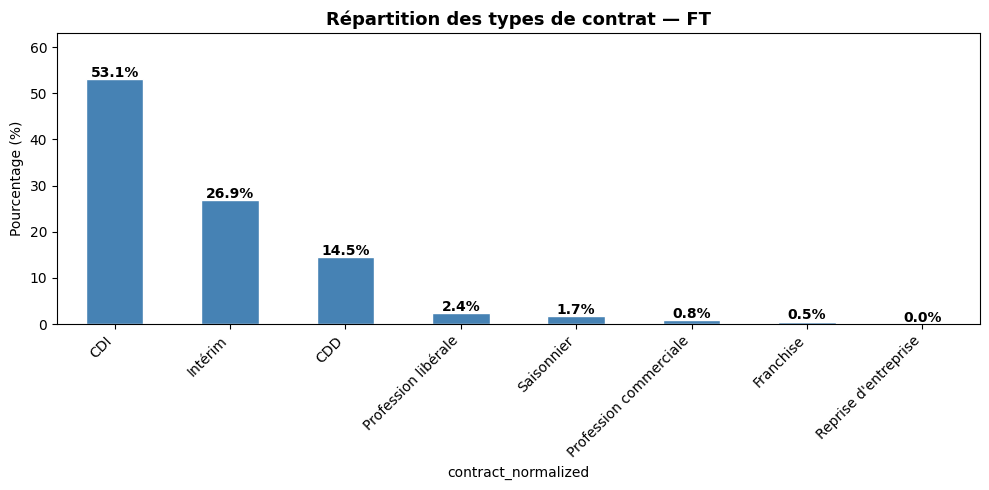

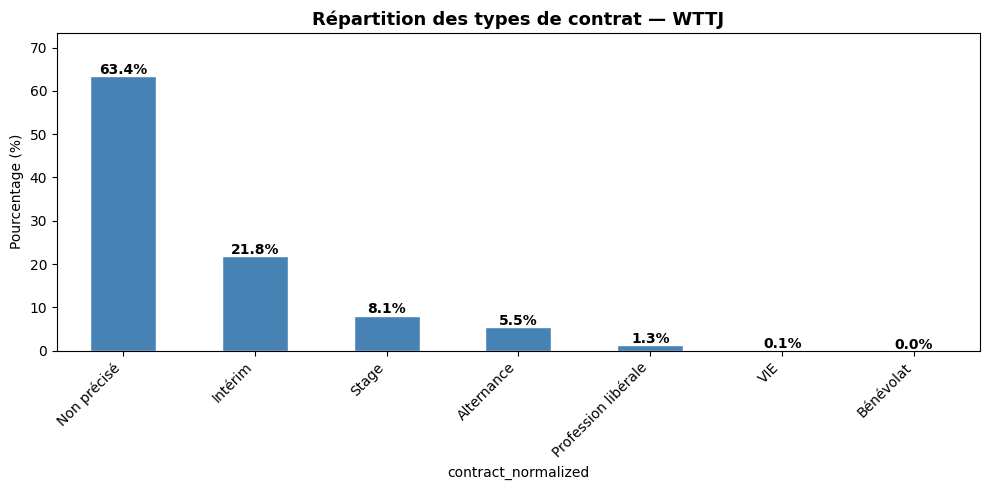

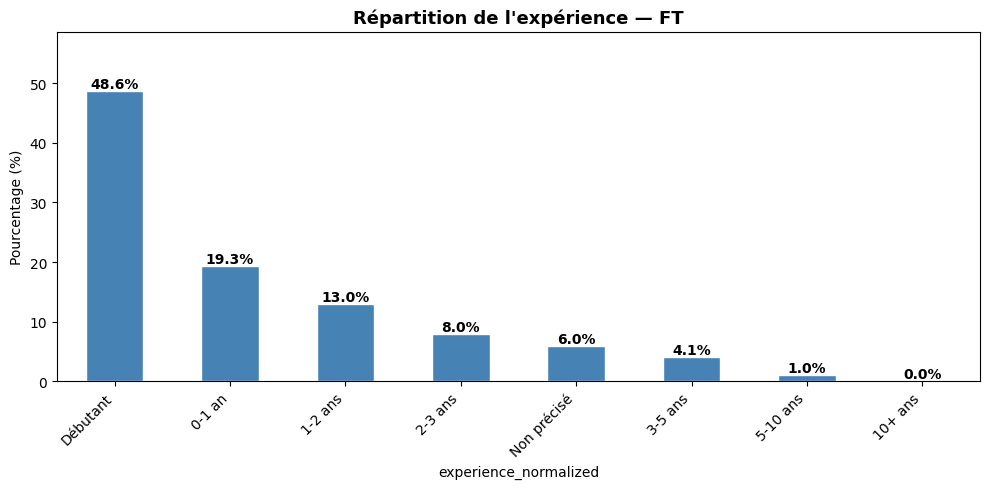

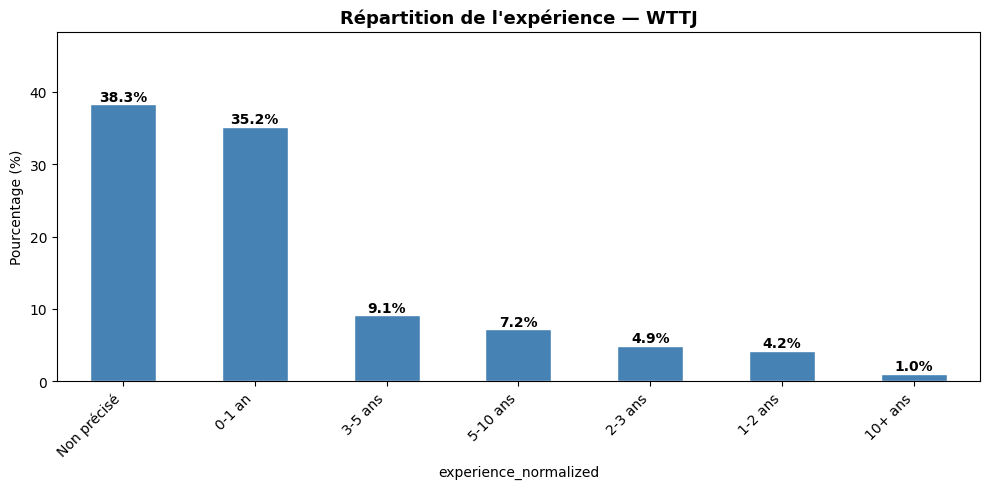

In [99]:
# Vérification de contract_normalized
plot_by_source(df, 'FT', 'Répartition des types de contrat' ,  'contract_normalized')
plot_by_source(df, 'WTTJ','Répartition des types de contrat', 'contract_normalized')

plot_by_source(df, 'FT', 'Répartition de l\'expérience',  'experience_normalized')
plot_by_source(df, 'WTTJ', 'Répartition de l\'expérience' , 'experience_normalized')



In [100]:
# ==========
# Contrat
# ==========
display(df.groupby('source')['contract_type'].value_counts().head(10))

# ==========
# Experience
# ==========
# Libellé
display(df.groupby('source')['experience_normalized'].value_counts().head(10))
# Index associé
display(df.groupby('source')['experience_index'].value_counts().head(10))

# Original mixed values  
#display(df.groupby('source')['experience_detail'].value_counts().head(10))
#display(df.groupby('source')['experience_source_composite'].value_counts().head(10))

# ==========
# Salaires
# ==========
display(df.groupby('source')['salary_min'].value_counts().head(10))
display(df.groupby('source')['salary_max'].value_counts().head(10))

display(df.groupby('source')['yearly_min'].value_counts().head(10))
display(df.groupby('source')['yearly_max'].value_counts().head(10))





source  contract_type      
FT      CDI                    310967
        Intérim - 1 Mois        46338
        Intérim - 6 Mois        26211
        Intérim - 3 Mois        20389
        CDD - 6 Mois            17259
        CDD - 12 Mois           15601
        Profession libérale     14215
        Intérim - 18 Mois       13484
        Intérim - 12 Mois        7801
        CDD - 3 Mois             7784
Name: count, dtype: int64

source  experience_normalized
FT      Débutant                 285347
        0-1 an                   113341
        1-2 ans                   76083
        2-3 ans                   46673
        Non précisé               35276
        3-5 ans                   24117
        5-10 ans                   5717
        10+ ans                     214
WTTJ    Non précisé               17245
        0-1 an                    15852
Name: count, dtype: int64

source  experience_index
FT       0                  285347
         1                  113341
         2                   76083
         3                   46673
        -1                   35276
         4                   24117
         5                    5717
         6                     214
WTTJ    -1                   17245
         1                   15852
Name: count, dtype: int64

source  salary_min
FT      12.02         44583
        30000.00      14215
        25000.00      12123
        13.00         11623
        35000.00       7466
        2000.00        6663
        40000.00       6114
        1764.00        5288
        2500.00        3680
        0.00           3589
Name: count, dtype: int64

source  salary_max
FT      35000.00      10529
        13.00         10417
        40000.00      10277
        14.00         10013
        30000.00       9469
        15.00          7533
        45000.00       6496
        12.02          6405
        2500.00        5477
        50000.00       4619
Name: count, dtype: int64

source  yearly_min
FT      21876.4       44501
        30000.0       17606
        25000.0       11988
        23660.0       11566
        24000.0        8241
        35000.0        7333
        40000.0        5978
        21168.0        5288
        22800.0        3622
        26400.0        3582
Name: count, dtype: int64

source  yearly_max
FT      30000.0       14770
        35000.0       10389
        23660.0       10359
        40000.0       10171
        25480.0        9955
        27300.0        7591
        45000.0        6359
        21876.4        6326
        50000.0        4539
        25000.0        4436
Name: count, dtype: int64

In [101]:
#df_copy = df.copy()
df = merge_utils.normalize_salary(df)

2026-03-13 08:48:51,616 - INFO - ✅ Start normalize_salary
2026-03-13 08:48:52,870 - INFO - Outliers : yearly > 80,000.0, zero as indeterminate: True
2026-03-13 08:48:52,873 - INFO - Mise à None de yearly_min/yearly_max pour 379,728 lignes (salaire brut nul ou NaN)
2026-03-13 08:48:52,888 - INFO - Mise à None de yearly_min/yearly_max pour 4,324 lignes (salaire annuel > 80,000.0)
2026-03-13 08:48:54,213 - INFO - Exemples de lignes avec salaire min nul ou NaN ou > 80,000.0 :          id source                                                url  \
2   204VJNK     FT  https://candidat.francetravail.fr/offres/reche...   
6   204VBTR     FT  https://candidat.francetravail.fr/offres/reche...   
9   9773526     FT  https://candidat.francetravail.fr/offres/reche...   
10  9772425     FT  https://candidat.francetravail.fr/offres/reche...   
17  204TGNQ     FT  https://candidat.francetravail.fr/offres/reche...   

                                                title  \
2   Chauffeur de tracteur c

In [102]:
df[df['salary_min_computed'] < 100][['salary_min_computed', 'yearly_min', 'periodicity']]

,salary_min_computed,yearly_min,periodicity


In [103]:
def plot_salary(df, column_name):

    salaries = df_copy[column_name].dropna()
    salaries = salaries[salaries > 0]
   
    # Histogramme complet
    plt.figure(figsize=(14, 4))
    sns.histplot(df_copy[column_name].dropna(), bins=200, kde=True)
    plt.title(f'Distribution complète des salaires {column_name} (avec outliers)')
    plt.xlabel('Salaire minimum')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    plt.show()

    # Scatterplot pour visualiser la dispersion et les outliers
    plt.figure(figsize=(14, 4))
    plt.scatter(range(len(df_copy)), df_copy[column_name].sort_values())
    plt.title(f'Scatterplot des salaires {column_name} (outliers visibles à droite)')
    plt.xlabel('Index')
    plt.ylabel('Salaire minimum')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    plt.show()
     
    plt.figure(figsize=(12, 4))
    sns.scatterplot(x=np.arange(len(salaries)), y=salaries, alpha=0.5, label='Salaires')
    plt.axhline(salaries.mean(), color='red', linestyle='--', label='Moyenne')
    plt.axhline(salaries.median(), color='green', linestyle='-.', label='Médiane')
    plt.legend()
    plt.title(f'Nuage de points des salaires avec moyenne et médiane ({column_name})')
    plt.xlabel('Index')
    plt.ylabel('Salaire')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    plt.show()
        
    # Calcul des déciles
    deciles = np.percentile(salaries, np.arange(0, 110, 10))
    # Supprimer les doublons de déciles
    unique_deciles = np.unique(deciles)
    labels = [f"{int(unique_deciles[i])}-{int(unique_deciles[i+1])}" for i in range(len(unique_deciles)-1)]
    df_decile = pd.cut(salaries, bins=unique_deciles, labels=labels, include_lowest=True)
    decile_counts = df_decile.value_counts().sort_index()
    
    # Box Plot déciles
    plt.figure(figsize=(10, 5))
    sns.barplot(x=decile_counts.index, y=decile_counts.values)
    plt.title(f"Répartition des salaires par décile ({column_name})")
    plt.xlabel("Décile de salaire (€)")
    plt.ylabel("Nombre d'offres")
    plt.xticks(rotation=45)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    plt.show()
    
    # Violin
    plt.figure(figsize=(6, 4))
    sns.violinplot(y=salaries)
    plt.title(f'Violin plot des salaires ({column_name})')
    plt.ylabel('Salaire')
    ax = plt.gca()    
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    plt.show()

    # Box Plot quartile 
    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(y=salaries)
    quartiles = np.percentile(salaries, [25, 50, 75])
    for q, label in zip(quartiles, ['Q1 (25%)', 'Médiane (50%)', 'Q3 (75%)']):
        ax.axhline(q, color='red', linestyle='--', alpha=0.7)
        ax.text(0, q, f'{label}: {int(q)}', color='red', va='bottom', ha='left')
    plt.title(f'Boxplot des salaires avec quartiles ({column_name})')
    plt.ylabel('Salaire')
    ax = plt.gca()    
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', ' ')))
    plt.show()
    

In [104]:
#display(df[df['yearly_min'].isna()].head(1))
#display(df[ df['yearly_max'].isna()].head(1))

#display(df[ df['salary_max']>150000][['source','title','description','salary_min','salary_max','yearly_min','yearly_max','salary_periodicity','periodicity']].head(5))
# Analyse salary min 
salary_min_counts = df.groupby('salary_min').size().reset_index(name='count')
display(salary_min_counts.sort_values('count', ascending=False).head(10))

# Analyse salary max 
salary_max_counts = df.groupby('salary_max').size().reset_index(name='count')
display(salary_max_counts.sort_values('count', ascending=False).head(50))


,salary_min,count
40,12.02,44583
6697,30000.00,14215
6262,25000.00,12123
138,13.00,11623
6943,35000.00,7466
3052,2000.00,6663
7061,40000.00,6114
2114,1764.00,5288
4627,2500.00,3680
0,0.00,3589


,salary_max,count
4497,35000.00,10529
125,13.00,10417
4637,40000.00,10277
223,14.00,10013
4281,30000.00,9469
312,15.00,7533
4743,45000.00,6496
27,12.02,6405
2532,2500.00,5477
4806,50000.00,4619


In [105]:
# Analyse salary min 
salary_min_counts = df.groupby('salary_min_computed').size().reset_index(name='count')
display(salary_min_counts.sort_values('count', ascending=False).head(10))

# Analyse salary max 
salary_max_counts = df.groupby('salary_max_computed').size().reset_index(name='count')
display(salary_max_counts.sort_values('count', ascending=False).head(50))


,salary_min_computed,count
276,21876.4,44501
3636,30000.0,17606
1876,25000.0,11988
1208,23660.0,11566
1376,24000.0,8241
4474,35000.0,7333
4863,40000.0,5978
157,21168.0,5288
809,22800.0,3622
2534,26400.0,3582


,salary_max_computed,count
2853,30000.0,14788
3615,35000.0,10391
1389,23660.0,10386
4029,40000.0,10175
1852,25480.0,9968
2316,27300.0,7592
4297,45000.0,6360
955,21876.4,6327
4446,50000.0,4540
1732,25000.0,4468


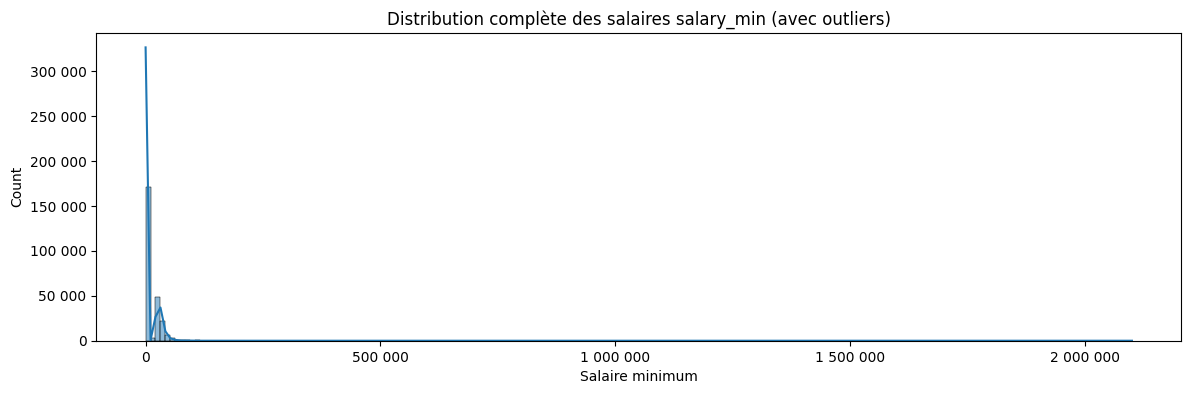

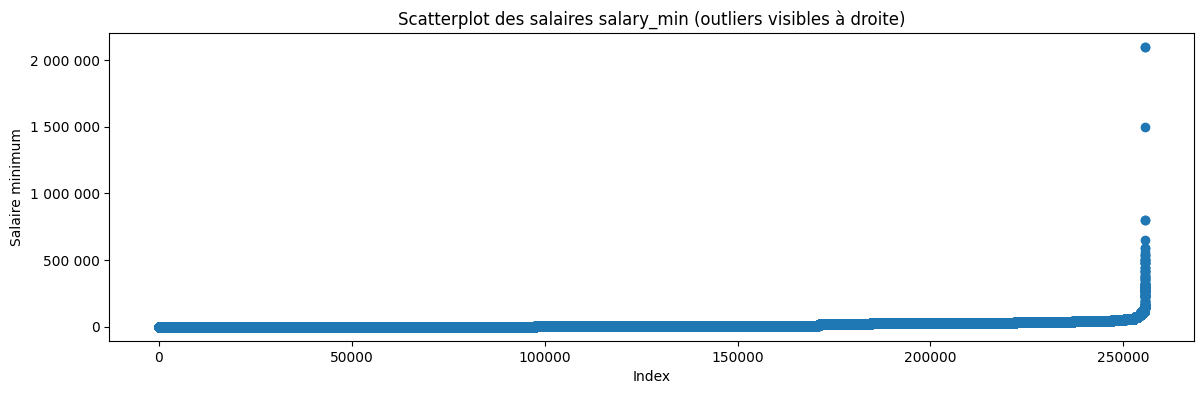

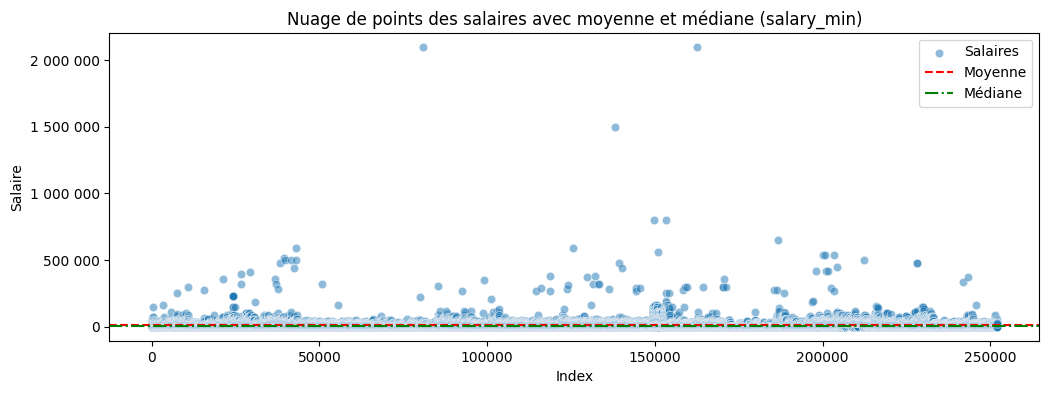

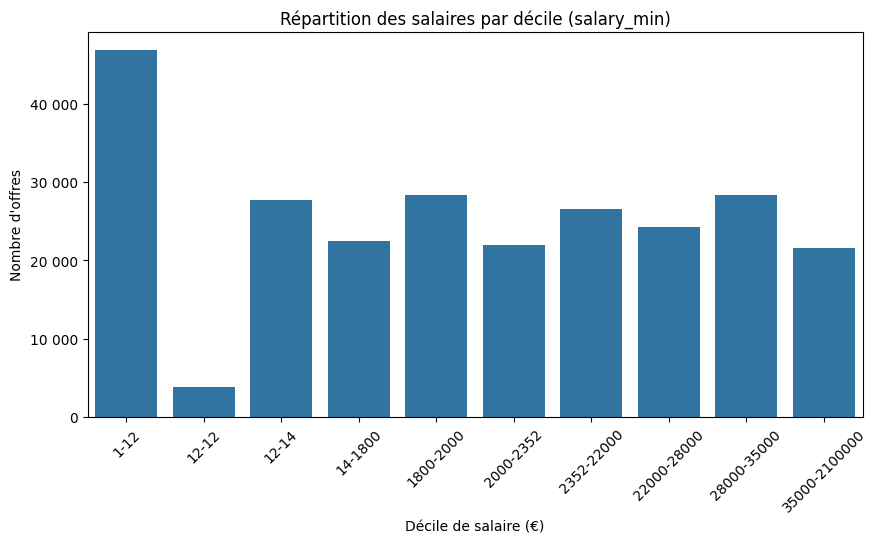

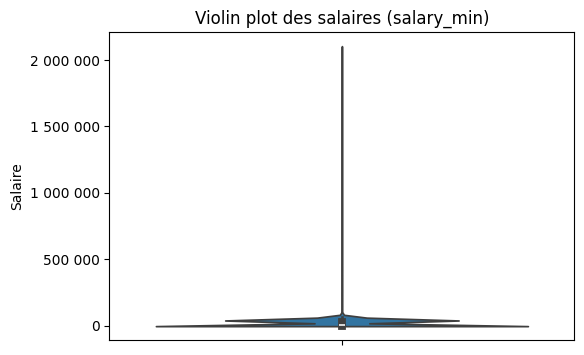

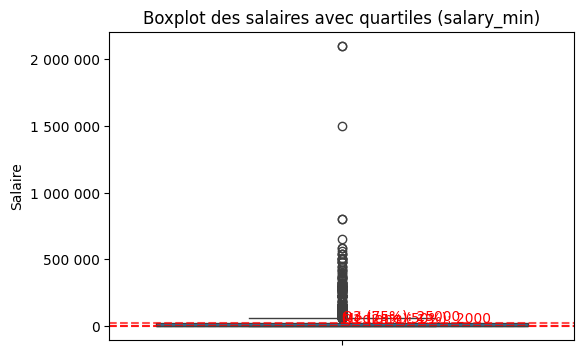

In [106]:
plot_salary(df, "salary_min")


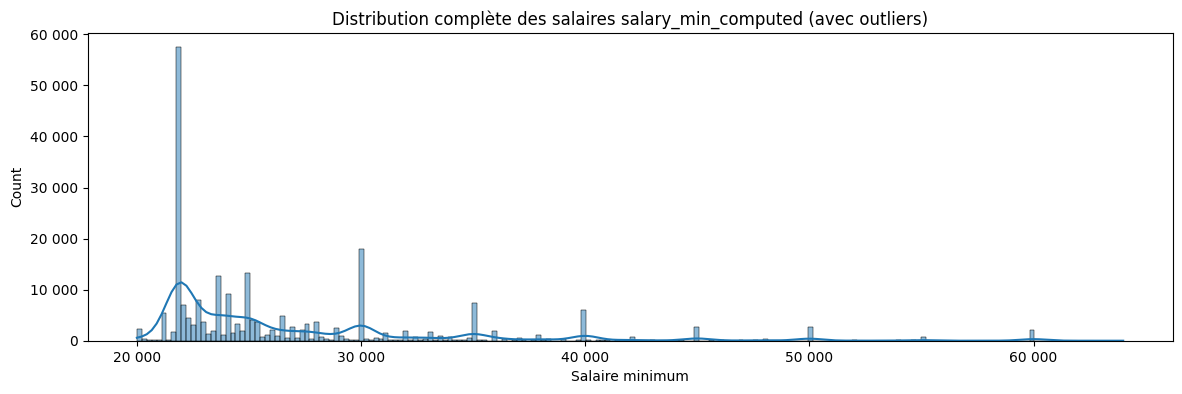

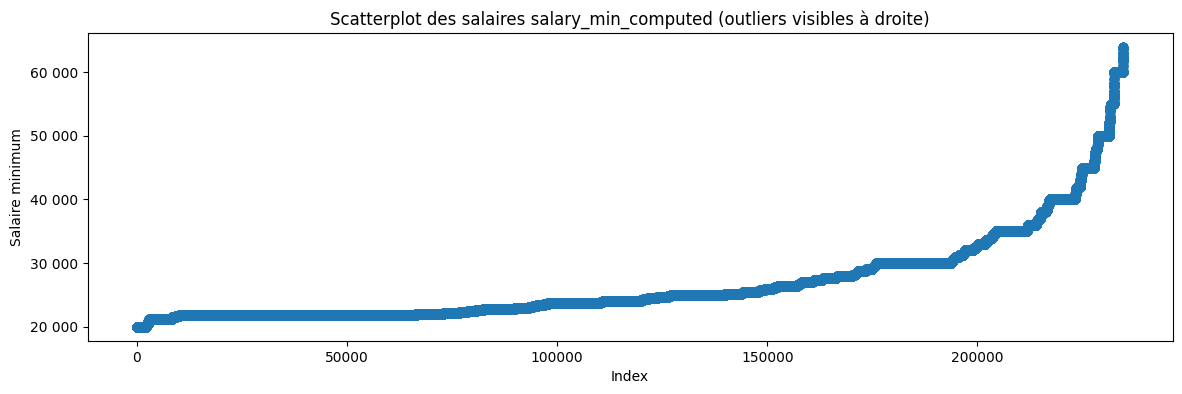

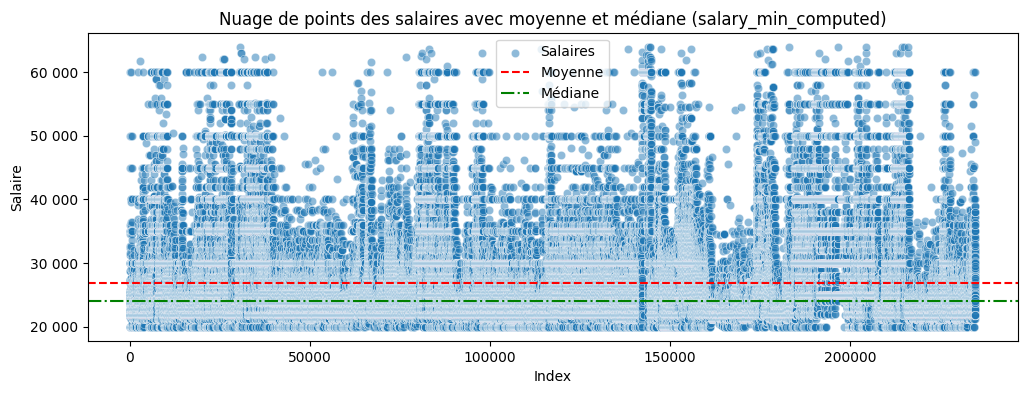

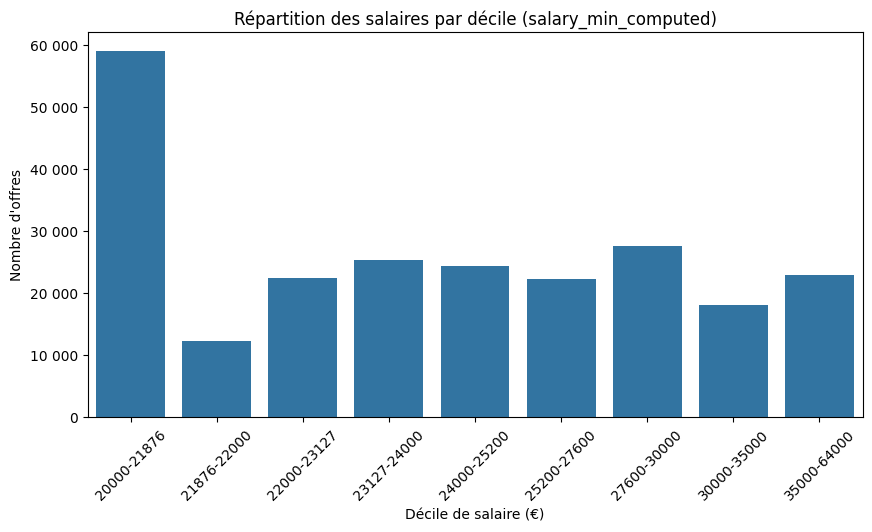

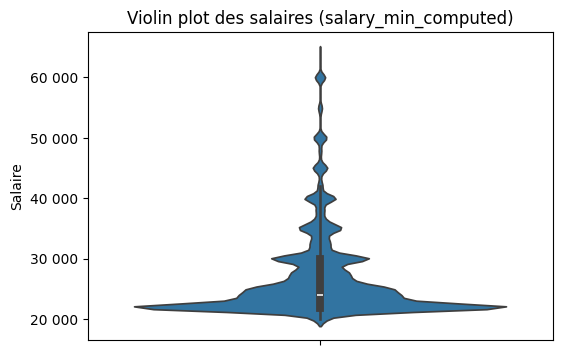

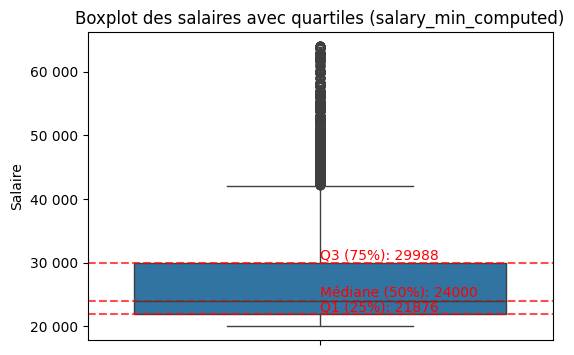

In [107]:
plot_salary(df, "salary_min_computed")

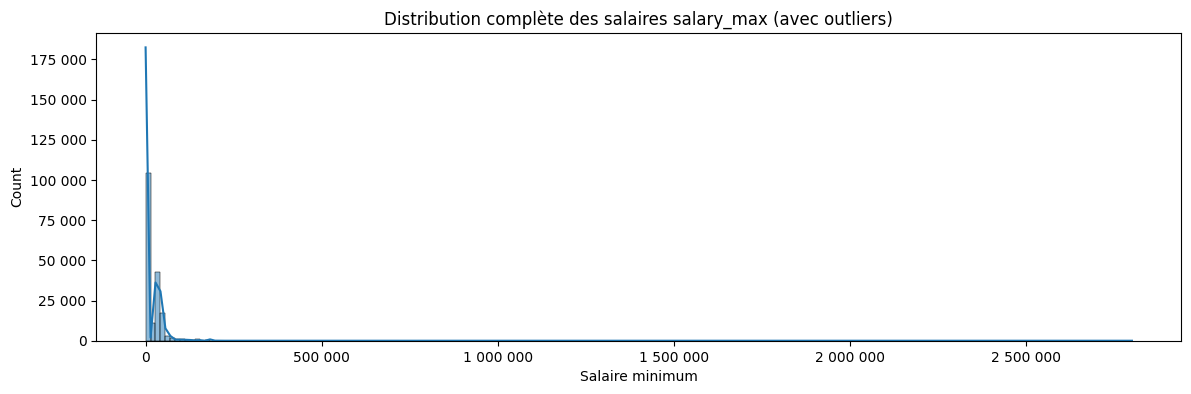

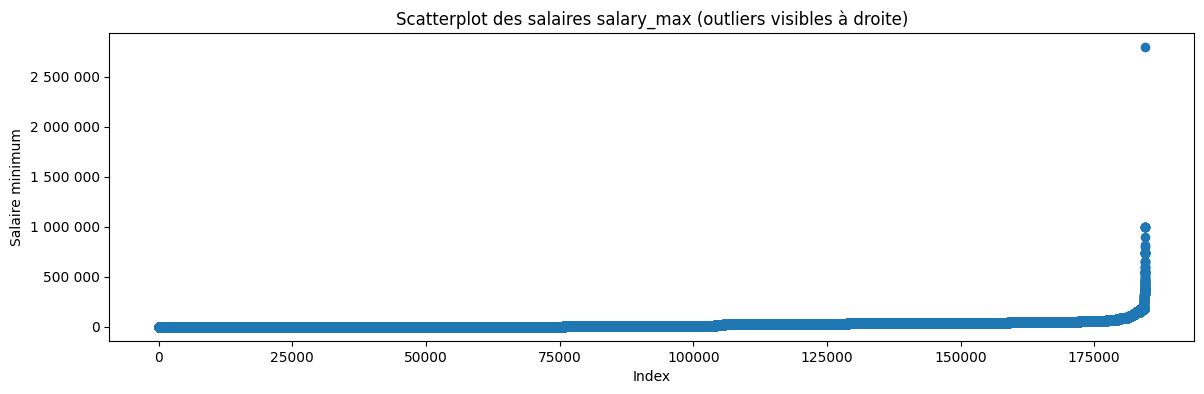

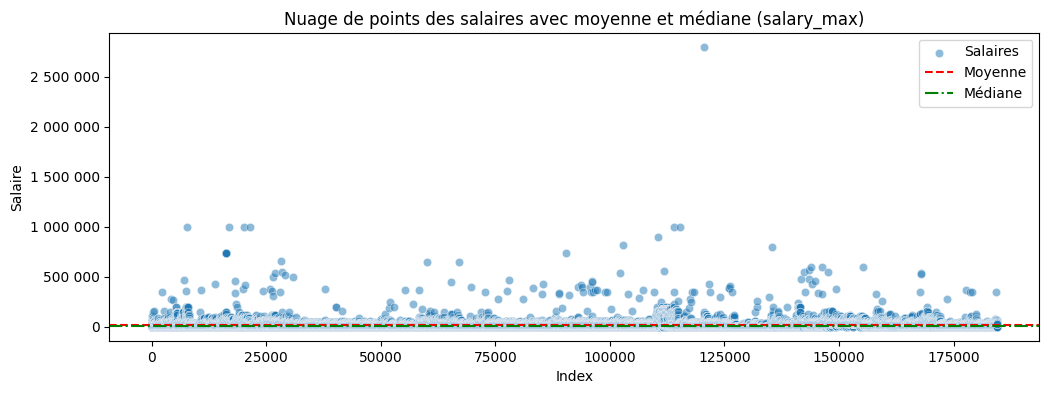

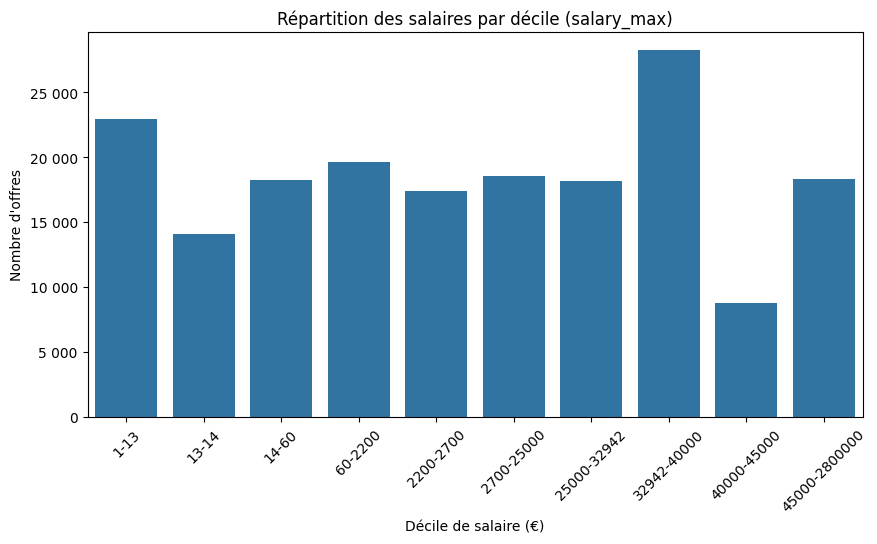

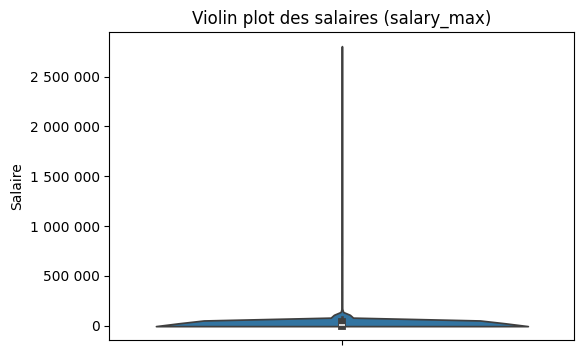

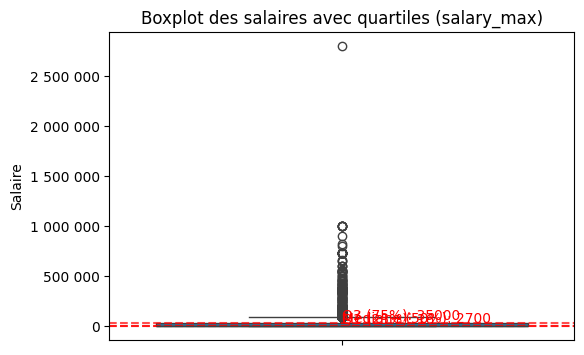

In [108]:
plot_salary(df, "salary_max")

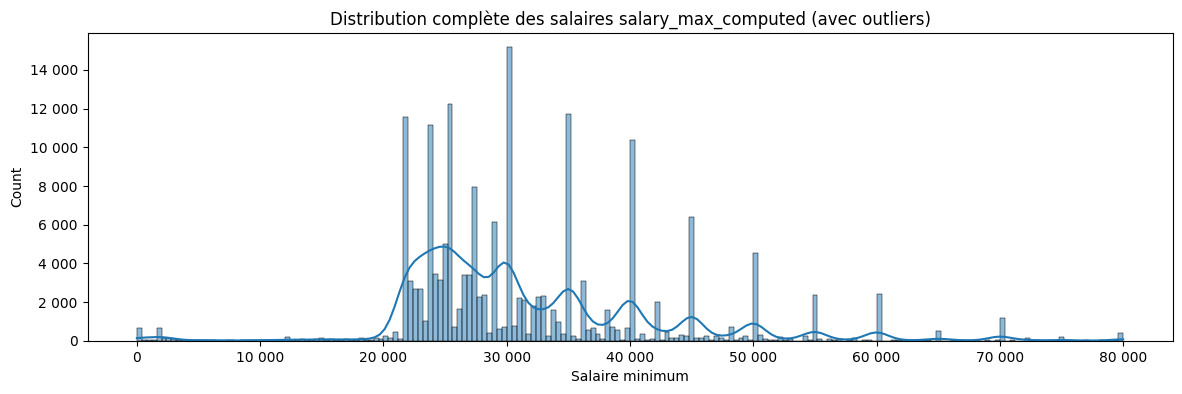

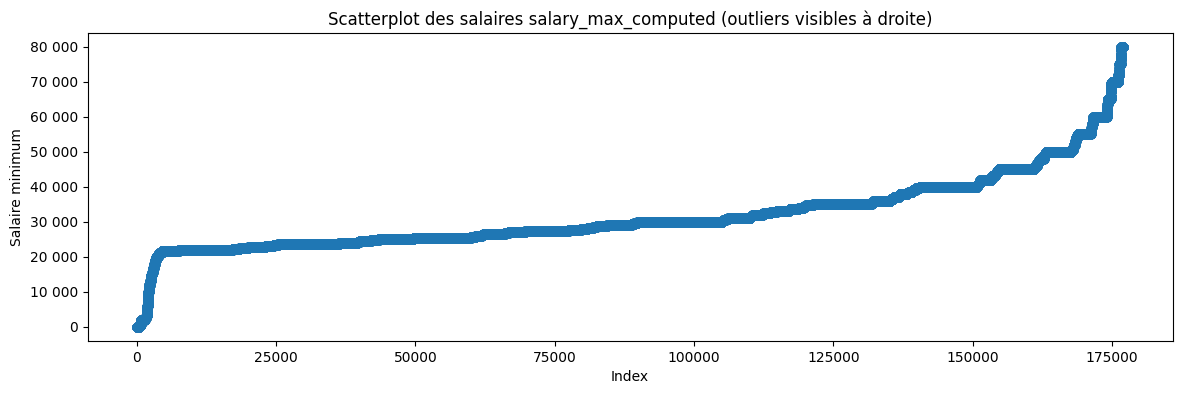

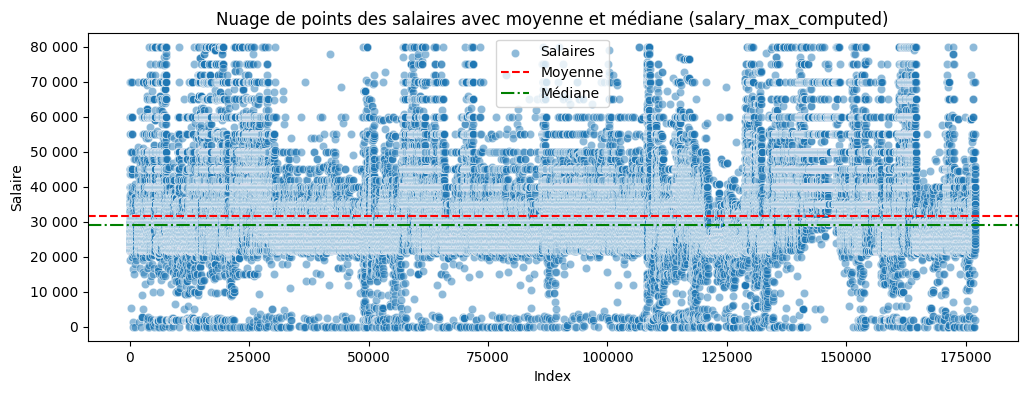

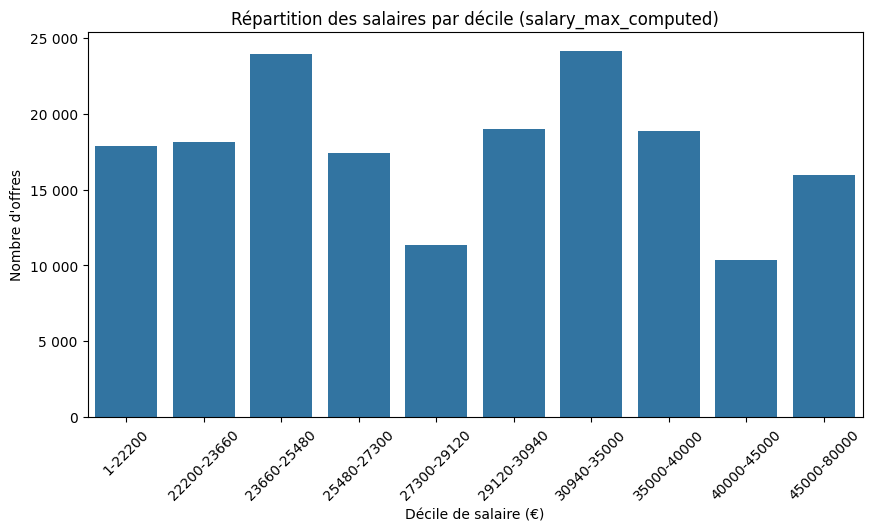

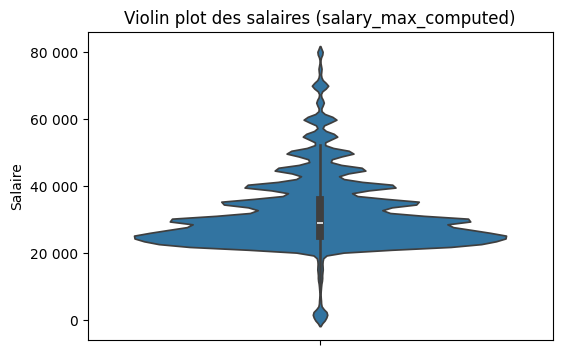

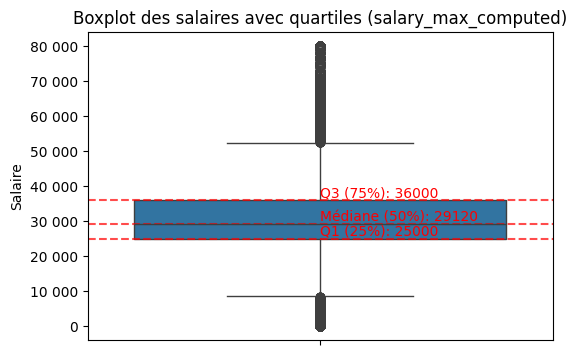

In [109]:
plot_salary(df, "salary_max_computed")

In [110]:
if df is not None and not df.empty:
    merge_utils.print_statistics_salaries(df)
else    :
    logger.warning("⚠️ Aucune donnée chargée pour les statistiques FT/WTTJ fusionnées")


📊 STATISTICS OF THE MERGED DATASET

📈 GLOBAL STATISTICS
   Total offers: 631,758

💰 SALARY
   Raw salary field set  : 255,619 (40.5%)
   No salary info        : 376,139 (59.5%)

💰 SALARY — AFTER NORMALIZATION
   Periodicity extracted : 255,612 (40.5%)
      Annuel    : 88,159 (14.0%)
      Horaire   : 84,068 (13.3%)
      Mensuel   : 83,385 (13.2%)
   salary_min_computed extracted  : 234,683 (37.1%)
   salary_max_computed extracted  : 177,026 (28.0%)
   yearly_min computed   : 247,699 (39.2%)

   ── Salary details by periodicity ──
   Annuel (88,159 offres):
      Raw  min : avg=    31,606  min=    20,000  max=    64,000
      Raw  max : avg=    37,575  min=         0  max=    80,000
      Year min : avg=    31,238  min=         1  max=    80,000
      Year max : avg=    40,978  min=         1  max= 1,000,000
      ⚠ Max outlier (raw_min=64,000):
           id                  : 9293617
           source              : FT
           title               : Responsable Communication Inte

## Contracts

In [111]:
# contract_counts = df['contract_type'].value_counts()
contract_counts_by_source = df.groupby('source')['contract_type'].value_counts()

### Avant normalisation

In [112]:
display(contract_counts_by_source.head(30))
#print(f" Libellé unique = {len(contract_counts_by_source)}")


source  contract_type         
FT      CDI                       310967
        Intérim - 1 Mois           46338
        Intérim - 6 Mois           26211
        Intérim - 3 Mois           20389
        CDD - 6 Mois               17259
        CDD - 12 Mois              15601
        Profession libérale        14215
        Intérim - 18 Mois          13484
        Intérim - 12 Mois           7801
        CDD - 3 Mois                7784
        Intérim - 4 Mois            7676
        Intérim - 2 Mois            7283
        CDD - 1 Mois                7037
        CDD - 36 Mois               6021
        CDD - 2 Mois                5335
        CDD - 24 Mois               4530
        Profession commerciale      4379
        CDD - 4 Mois                3378
        Franchise                   3030
        Intérim - 5 Mois            2984
        Saisonnier - 6 Mois         2768
        CDD - 5 Mois                2653
        CDD - 18 Mois               2584
        CDD - 7 Mois      

### Après normalisation 

In [113]:
def normalize_contracts(df, patterns):
    """
    Normalise les types de contrat :
    - Extrait le type principal (CDI, CDD, Intérim, etc.)
    - Extrait le détail (durée, précision)
    - Stocke dans contract_normalized et contract_detail
    """
    def extract_type(value):
        if pd.isna(value):
            return 'Inconnu'
        for pattern, label in patterns:
            if re.search(pattern, str(value)):
                return label
        return str(value)  # garder la valeur originale si pas de match

    def extract_detail(value):
        if pd.isna(value):
            return None
        # Supprimer le pattern trouvé et retourner le reste
        remaining = str(value)
        for pattern, label in patterns:
            remaining = re.sub(pattern, '', remaining).strip()
        # Nettoyer les séparateurs résiduels (-, :, espaces)
        remaining = re.sub(r'^[\s\-:]+|[\s\-:]+$', '', remaining)
        return remaining if remaining else None
    
    df = df.copy()
    df['contract_normalized'] = df['contract_type'].apply(extract_type)
    df['contract_detail']     = df['contract_type'].apply(extract_detail)
    
    return df


Modalités de contrats FT = 11
Modalités de contrats WTTJ = 10


source  contract_normalized                         
FT      CDI                                             311669
        Intérim                                         157945
        CDD                                              85304
        Profession libérale                              14239
        Saisonnier                                        9849
        Profession commerciale                            4704
        Franchise                                         3034
        Reprise d'entreprise                                21
        Contrat durée déterminée insertion - 12 Mois         1
        Reprise d'entreprise - 12 Mois                       1
        Contrat durée déterminée insertion - 24 Mois         1
WTTJ    full_time                                        27671
        temporary                                         9788
        internship                                        3628
        apprenticeship                                    2444
  

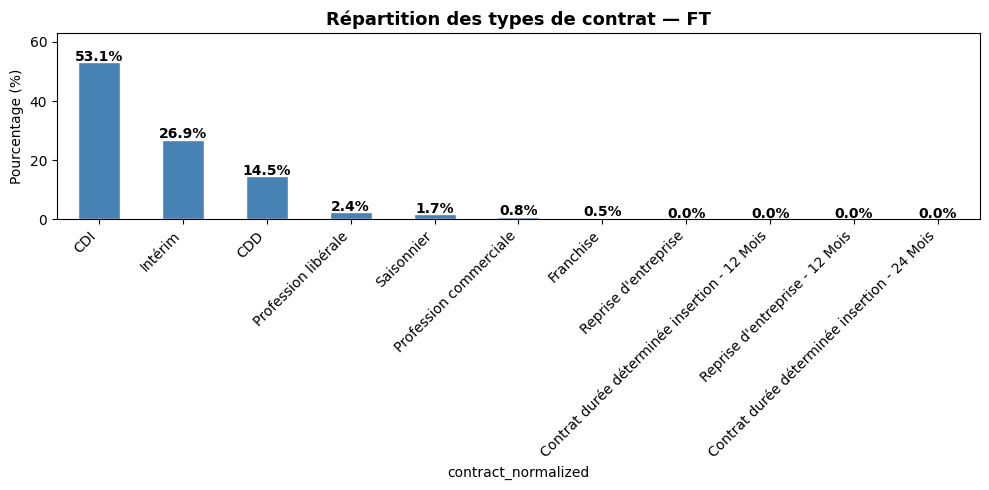

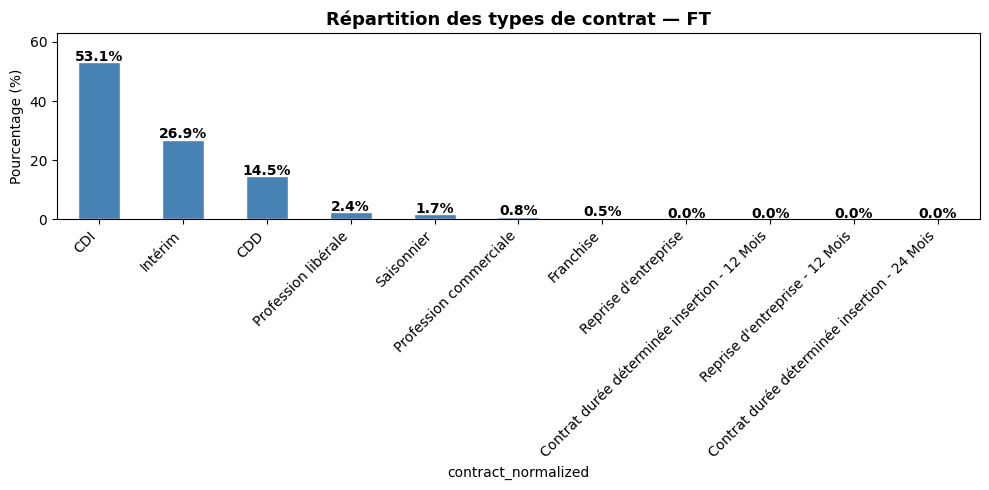

In [114]:
# Mapping des patterns => type normalisé
patterns = [
    (r'(?i)cdi',                'CDI'),
    (r'(?i)contrat à durée indéterminée',                'CDD'),
    (r'(?i)cdd',                'CDD'),
    (r'(?i)contrat à durée déterminée',                'CDD'),
    (r'(?i)profession\s+lib',   'Profession libérale'),
    (r'(?i)intér?im',           'Intérim'),
    (r'(?i)saisonnier',           'Saisonnier'),
    (r'(?i)profession commerciale',     'Profession commerciale'),
    (r'(?i)franchise',     'Franchise')    
]

# Apply
df_normalize = normalize_contracts(df, patterns)

df_normalize_contract_counts_by_source = df_normalize.groupby('source')['contract_normalized'].value_counts()
print(f"Modalités de contrats FT = {len(df_normalize_contract_counts_by_source.loc['FT'])}")
print(f"Modalités de contrats WTTJ = {len(df_normalize_contract_counts_by_source.loc['WTTJ'])}")

display(df_normalize_contract_counts_by_source.head(30))

plot_by_source(df_normalize, 'FT', 'Répartition des types de contrat' ,  'contract_normalized')
plot_by_source(df_normalize, 'FT', 'Répartition des types de contrat' ,  'contract_normalized')



### Expérience

In [115]:
experience_level_counts_by_source = df.groupby('source')['experience_level'].value_counts()
experience_description_counts_by_source = df.groupby('source')['experience_description'].value_counts()

### Avant normalisation

**FT**
- experienceExige => D : débutant accepté, E : l’expérience est exigée, S : l’expérience est souhaitée
- experienceLibelle => Libellé de l’expérience ex : Débutant accepté / 1 ans ... 
- experienceCommentaire => Commentaire sur l’expérience. Ex: Expérience dans la vente souhaitée

On a pas la bonne correspondance de colonne.
Il faut prendre `experience_level` pour `wttj` et `experience_description` pour FT


In [116]:
display(experience_level_counts_by_source.head(30))


source  experience_level  
FT      E                     307688
        D                     279066
        S                         14
WTTJ    LESS_THAN_6_MONTHS     14766
        5_TO_7_YEARS            2843
        4_TO_5_YEARS            2485
        2_TO_3_YEARS            2221
        1_TO_2_YEARS            1893
        3_TO_4_YEARS            1605
        6_MONTHS_TO_1_YEAR      1086
        7_TO_10_YEARS            416
        10_TO_15_YEARS           402
        MORE_THAN_15_YEARS        28
Name: count, dtype: int64

In [117]:
display(experience_description_counts_by_source.head(30))

source  experience_description          
FT      Débutant accepté                    276159
        1 An(s)                              91518
        2 An(s)                              67695
        3 An(s)                              42951
        Expérience exigée                    35264
        5 An(s)                              19507
        6 Mois                                9175
        0 An(s)                               4707
        12 Mois                               3976
        6 An(s)                               3660
        4 An(s)                               2605
        24 Mois                               1867
        3 Mois                                1555
        10 An(s)                              1335
        7 An(s)                               1233
        1 Mois                                 859
        36 Mois                                553
        2 Mois                                 523
        8 An(s)                          

In [118]:
# Définition des tranches d'expérience avec leurs indices
EXPERIENCE_LEVELS = [
    (0, 'Débutant',    [r'(?i)débutant', r'(?i)0 an', r'(?i)sans expérience']),
    (1, '0-1 an',      [r'(?i)^1 an', r'(?i)^6 mois', r'(?i)^1 mois', r'(?i)^3 mois', r'(?i)less_than_6_months', r'(?i)6_months_to_1_year']),
    (2, '1-2 ans',     [r'(?i)^2 an', r'(?i)1_to_2_years']),
    (3, '2-3 ans',     [r'(?i)^3 an', r'(?i)^24 mois', r'(?i)2_to_3_years' ]),
    (4, '3-5 ans',     [r'(?i)^4 an', r'(?i)^5 an', r'(?i)4_to_5_years', r'(?i)3_to_4_years']),
    (5, '5-10 ans',    [r'(?i)^6 an', r'(?i)^7 an', r'(?i)^8 an', r'(?i)^9 an', r'(?i)^10 an', r'(?i)5_to_7_years', r'(?i)7_to_10_years']),
    (6, '10+ ans',     [r'(?i)^1[1-9] an', r'(?i)^[2-9][0-9] an', r'(?i)10_to_15_years', r'(?i)more_than_15_years']),
    (-1, 'Non précisé', [r'(?i)expérience exigée', r'(?i)expérience souhaitée']),
   
]

def normalize_experience(df, experience_col):
    """
    Normalise les niveaux d'expérience :
    - experience_normalized : label lisible (ex: '0-1 an')
    - experience_index      : indice numérique (ex: 1) pour trier/comparer
    - experience_detail     : valeur originale nettoyée
    """

    def extract_experience(value):
        if pd.isna(value):
            #To DEBUG
            return -1, 'NAN', None
            #return -1, 'Non précisé', None
        
        str_value = str(value).strip()
        
        for index, label, patterns in EXPERIENCE_LEVELS:
            for pattern in patterns:
                if re.search(pattern, str_value):
                    # Détail = valeur originale
                    return index, label, str_value
        
        #return -1, 'Non précisé', str_value
        # To debug
        return -1, value, str_value
    

    results = df[experience_col].apply(extract_experience)
    
    df = df.copy()
    df['experience_index']      = results.apply(lambda x: x[0])
    df['experience_normalized'] = results.apply(lambda x: x[1])
    df['experience_detail']     = results.apply(lambda x: x[2])
    
    return df


In [119]:
def get_experience_col(row):
    if row['source'] == 'FT':
        return row['experience_description']
    elif row['source'] == 'WTTJ':
        return row['experience_level']
    else:
        return None 

df_normalize['experience_source_composite'] = df.apply(get_experience_col, axis=1)

# Utilisation
df_normalize = normalize_experience(df_normalize,'experience_source_composite')

# Vérification
#df_normalize[['experience_source_composite', 'experience_index', 'experience_normalized', 'experience_detail']].head(20)

display(df_normalize.groupby('source')['experience_normalized'].value_counts())

source  experience_normalized
FT      Débutant                 285311
        0-1 an                   112006
        1-2 ans                   71678
        2-3 ans                   46660
        Non précisé               35282
                                  ...  
WTTJ    3-5 ans                    4090
        5-10 ans                   3259
        2-3 ans                    2221
        1-2 ans                    1893
        10+ ans                     430
Name: count, Length: 434, dtype: int64

## ROME

In [120]:
rome_count = df['rome_code'].value_counts()


## Statistics from helper

In [121]:
if df is not None and not df.empty:
    merge_utils.print_statistics(df)
else    :
    logger.warning("⚠️ Aucune donnée chargée pour les statistiques FT/WTTJ fusionnées")


📊 STATISTICS OF THE MERGED DATASET

📈 GLOBAL STATISTICS
   Total offers: 631,758

📦 DISTRIBUTION BY SOURCE
   FT: 586,768 offers (92.9%)
   WTTJ: 44,990 offers (7.1%)

📌 ROME COVERAGE BY SOURCE
   FT: 586,768/586,768 offers with ROME (100.0%)
   WTTJ: 44,990/44,990 offers with ROME (100.0%)

🎯 ROME CODES
   Offers with ROME: 631,758 (100.0%)
   Unique ROME codes: 1506

🏆 TOP 10 ROME CODES
   K1304: 11,953 (1.9%) - Employé familial / Employée familiale
   J1506: 10,657 (1.7%) - Infirmier / Infirmière en soins généraux (IDE)
   J1501: 10,612 (1.7%) - Aide-soignant / Aide-soignante
   C1504: 10,372 (1.6%) - Conseiller / Conseillère immobilier
   M1211: 9,970 (1.6%) - Expert-comptable / Experte-comptable
   M1203: 8,977 (1.4%) - Comptable
   I1304: 7,611 (1.2%) - Technicien / Technicienne de maintenance industrielle
   K1311: 7,509 (1.2%) - Assistant / Assistante de vie aux familles
   D1507: 7,069 (1.1%) - Employé / Employée de rayon libre-service
   H2903: 6,828 (1.1%) - Tourneur-fraise